# Automatic differentiation from scratch

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Nov 19, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Nov 19, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code and comments improvements |

## 1. Introduction

In optimization, we need gradients. There are three ways to compute derivatives:

* **Symbolic Differentiation:** It is performed by hand or using a computer algebra system like Maxima or SymPy. It gives exact expressions but may lead to "expression swell" (formulas become exponentially large).
* **Numerical Differentiation:** Uses finite differences that approximate derivatives: $f'(x) \approx \frac{f(x+h) - f(x)}{h}$. It is slow and suffers from floating-point errors.
* **Automatic Differentiation (AutoDiff):** The efficient, exact evaluation of derivatives by decomposing functions into elementary operations and applying the Chain Rule.

Today, we will build Forward Mode and Reverse Mode AutoDiff from scratch using Python's operator overloading. We will calculate the gradients of:
$$
f(x_1, x_2) = \ln(x_1) + x_1 x_2 - \sin(x_2)
$$

-----

## 2. Forward mode AD

Forward mode computes the value of the function and its derivative simultaneously in a single pass.

To calculate $f(x_1, x_2) = \ln(x_1) + x_1 x_2 - \sin(x_2)$, we need to implement a `Dual` class that supports overloaded operators such as addition, substraction, multiplication, sines, and natural log. This class will apply the chain rule.

In [11]:
import math

class Dual:
    def __init__(self, val, der):
        self.val = val
        self.der = der

    def __repr__(self):
        return f"Dual(val={self.val:.4f}, der={self.der:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Dual) else Dual(other, 0)
        return Dual(self.val + other.val, self.der + other.der)

    def __sub__(self, other):
        other = other if isinstance(other, Dual) else Dual(other, 0)
        return Dual(self.val - other.val, self.der - other.der)

    def __mul__(self, other):
        # Chain rule for product: d/dx (uv) = u'v + uv'
        other = other if isinstance(other, Dual) else Dual(other, 0)
        return Dual(self.val * other.val, self.val*other.der + self.der*other.val)

    def __pow__(self, n):
        # Chain rule for power: d/dx u^n = n*u^(n-1) * u'
        return Dual(self.val ** n, n*(self.val**(n - 1)) * self.der)

    def log(self):
        # Chain rule for ln(u): d/dx ln(u) = (1/u)*u'
        return Dual(math.log(self.val), (1/self.val)*self.der)

    def sin(self):
        # Chain rule for sin(u): d/dx sin(u) = cos(u) * u'
        return Dual(math.sin(self.val), math.cos(self.val)*self.der)

### Testing Forward Mode
Let's analytically compute the derivatives of $f(x_1, x_2) = \ln(x_1) + x_1 x_2 - \sin(x_2)$:
\begin{align*}
\frac{\partial f}{\partial x_1} &= \frac{1}{x_1} + x_2 \\
\frac{\partial f}{\partial x_2} &= x_1 - \cos(x_2)
\end{align*}

At $(x_1, x_2) = (2, 5)$, we have:
\begin{alignat*}{2}
\frac{\partial f}{\partial x_1} &= \frac{1}{2} + 5 &&= 5.5 \\
\frac{\partial f}{\partial x_2} &= 2 - \cos(5) &&= 1.7163
\end{alignat*}

Because Forward Mode calculates derivatives with respect to *one seed variable* at a time, calculating the gradient for a function with **two inputs** ($x_1, x_2$) requires **two passes**:

1.  Seed $x_1$ (derivative=1) and $x_2$ (derivative=0) to get $\frac{\partial f}{\partial x_1}$.
2.  Seed $x_1$ (derivative=0) and $x_2$ (derivative=1) to get $\frac{\partial f}{\partial x_2}$.

In [12]:
# Let's evaluate at x1=2.0, x2=5.0
val_x1, val_x2 = 2.0, 5.0

# PASS 1: Compute partial derivative w.r.t x1
# We set x1's derivative seed to 1, and x2's to 0 (treating x2 as a constant)
x1 = Dual(val_x1, 1.0)
x2 = Dual(val_x2, 0.0)
y = x1.log() + x1*x2 - x2.sin()
print(f"y      = {y.val:.4f}")
print(f"df/dx1 = {y.der:.4f}")

# PASS 2: Compute partial derivative w.r.t x2
# We set x1's derivative seed to 0, and x2's to 1 (treating x1 as a constant)
x1 = Dual(val_x1, 0.0)
x2 = Dual(val_x2, 1.0)
# y = x1.log() + x1*x2 - x2.sin()
y = Dual.log(x1) + x1*x2 - Dual.sin(x2)
print(f"df/dx2 = {y.der:.4f}")

y      = 11.6521
df/dx1 = 5.5000
df/dx2 = 1.7163


Forward mode is highly efficient if you have few inputs and many outputs. However, if you have millions of input variables and one output variable, running "Forward mode AD" would require a separate pass for every single input variable. This is why we need "Reverse mode AD".

-----

## 3. Reverse mode AD

Reverse Mode works in two phases:

* **Forward pass:** Compute the output and build a "Computational Graph" (remembering the history of operations).

* **Backward pass:** Traverse the graph in reverse to compute gradients.

We will create a class called `Value`. Each `Value` object will remember which parents created it and how to calculate the gradient with respect to them.

Notice the `+=` in all backward functions. This handles nodes with multiple outgoing edges (e.g., `x1` used twice). All gradient contributions are summed.

In [13]:
class Value:
    def __init__(self, val, _parents=(), _op='', label=''):
        self.val = val     # The numerical value
        self.grad = 0.0    # d(output)/d(this node)

        # This function stores the specific chain rule logic for the operation
        # that created this node. It is None for leaf nodes (inputs).
        self._backward = lambda: None   # Function to call during backprop

        self._parents = set(_parents)   # Parents nodes (inputs to this op)
        self._op = _op                  # Operation type (for visualization)
        self.label = label              # Added label for visualization

    def __repr__(self):
        return f"Value(val={self.val:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        # Ensure 'other' is a Value object so we can access its attributes
        other = other if isinstance(other, Value) else Value(other)

        # 1. Forward Pass: Create the new node
        out   = Value(self.val + other.val, (self, other), '+')

        # 2. Backward Pass Definition: Define how gradients flow backward through
        # addition
        def _backward():
            # Local Derivative: d(x+y)/dx = 1.
            # Chain Rule: input_grad += output_grad * 1
            # We use += to accumulate gradients because a variable might be used
            # multiple times.
            self.grad  += out.grad
            other.grad += out.grad

        # Store this closure in the output node to be called later
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val - other.val, (self, other), '-')

        # Define how to propagate gradient backward during the reverse pass
        def _backward():
            # Local Derivative: d(x-y)/dx = 1, d(x-y)/dy = -1
            self.grad  += out.grad
            other.grad -= out.grad # Gradient flips sign
        out._backward = _backward
        return out

    def __rsub__(self, other):
        return self.__sub__(other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val * other.val, (self, other), '*')

        # Define how to propagate gradient backward during the reverse pass
        def _backward():
            # Local Derivative: d(x*y)/dx = y, d(x*y)/dy = x
            # Chain Rule: input_grad += output_grad * local_derivative

            # dL/dself  = dL/dout * dout/dself  = out.grad * other.val
            self.grad  += out.grad * other.val

            # dL/dother = dL/dout * dout/dother = out.grad * self.val
            other.grad += out.grad * self.val
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val / other.val, (self, other), '/')

        # Define how to propagate gradient backward during the reverse pass
        def _backward():
            # Local Derivative: d(x/y)/dx = 1/y, d(x/y)/dy = -x/y^2
            # Chain Rule: input_grad += output_grad * local_derivative

            # dL/dself  = dL/dout * dout/dself  = out.grad * other.val
            self.grad  += out.grad * (1/other.val)
            # dL/dother = dL/dout * dout/dother = out.grad * self.val
            other.grad -= out.grad * self.val/(other.val**2)
        out._backward = _backward
        return out

    def __rtruediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return other.__truediv__(self)

    def __pow__(self, n):
        out   = Value(self.val**n, (self,), '**')

        # Define how to propagate gradient backward during the reverse pass
        def _backward():
            # Local Derivative: d(x^n)/dx = n*x^(n-1)
            # Chain Rule: input_grad += output_grad * local_derivative

            # dL/dself  = dL/dout * dout/dself  = out.grad * other.val
            self.grad  += out.grad * n*self.val**(n - 1)
        out._backward = _backward
        return out

    def __neg__(self):
        out   = Value(-self.val, (self,), 'neg')
        def _backward():
            self.grad -= out.grad
        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.val), (self,), 'log')
        def _backward():
            # dL/dself  = dL/dout * dout/dself  = out.grad * other.val
            # d/dx ln(x) = 1/x
            self.grad += out.grad * (1/self.val)
        out._backward = _backward
        return out

    def sin(self):
        out = Value(math.sin(self.val), (self,), 'sin')
        def _backward():
            # dL/dself  = dL/dout * dout/dself  = out.grad * other.val
            # d/dx sin(x) = cos(x)
            self.grad += out.grad * math.cos(self.val)
        out._backward = _backward
        return out

    def backward(self):
        # This method uses a topological sort to traverse the computational
        # graph in reverse order, calling each node's _backward function to
        # compute and accumulate gradients for all upstream variables,
        # starting with an initial gradient of 1.0 for the output.

        # We need to order nodes so we compute dependencies first
        # (parents come before children)
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)

                # Recursively visit all parents (inputs) first
                for parent in v._parents:
                    build_topo(parent)

                # Append *after* visiting parents
                topo.append(v)
        build_topo(self)

        # Seed the output gradient (dLoss/dLoss = 1)
        self.grad = 1.0

        # Each operation's _backward() is triggered in reverse order
        # Those += accumulate derivatives using the chain rule
        for node in reversed(topo):
            node._backward()       # propagate gradient to parents

Now, let's evaluate the derivatives. Notice we only run the code **once** to get gradients for both inputs.

In [14]:
# Let's evaluate the derivatives at x1=2.0, x2=5.0
x1 = Value(2.0)
x2 = Value(5.0)

# Forward pass
y = Value.log(x1) + x1*x2 - Value.sin(x2)
print(f"y      = {y.val:.4f}")

# Backward pass
y.backward()
print(f"df/dx1 = {x1.grad:.4f}")
print(f"df/dx2 = {x2.grad:.4f}")

y      = 11.6521
df/dx1 = 5.5000
df/dx2 = 1.7163


# Computational graph visualization

Let's create a function that shows the computational graph.

To visualize the graph, we will use the `graphviz` library. This shows exactly how PyTorch visualizes models internally.



In [15]:
from graphviz import Digraph # Requires: pip install graphviz

def draw_dot(root):
    dot = Digraph(format='png', graph_attr={'rankdir': 'LR'}) # Left to Right

    nodes, edges = set(), set()
    def trace(root):
        if root not in nodes:
            nodes.add(root)
            for parent in root._parents:
                edges.add((parent, root))
                trace(parent)
    trace(root)

    for n in nodes:
        # Create a unique ID for the node based on memory address
        uid = str(id(n))
        # Label shows val, Gradient, and Operation
        label = "{ %s \\n val = %.4f \\n grad = %.4f }" % (n.label if n.label else '', n.val, n.grad)
        dot.node(name=uid, label=label, shape='record')
        if n._op:
            # Create a separate node for the operation symbol
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect nodes to their operation
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

### Execution and visualization

Now we run the "Reverse Mode" calculation. We break it down to ensure labels/ops are clear

f      = 11.6521
Value(val=11.6521, grad=0.0000)
Value(val=0.6931, grad=0.0000)
Value(val=10.0000, grad=0.0000)
Value(val=-0.9589, grad=0.0000)
Value(val=2.0000, grad=0.0000)
Value(val=5.0000, grad=0.0000)
----------
Value(val=11.6521, grad=1.0000)
Value(val=0.6931, grad=1.0000)
Value(val=10.0000, grad=1.0000)
Value(val=-0.9589, grad=-1.0000)
Value(val=2.0000, grad=5.5000)
Value(val=5.0000, grad=1.7163)
df/dx1 = 5.5000
df/dx2 = 1.7163


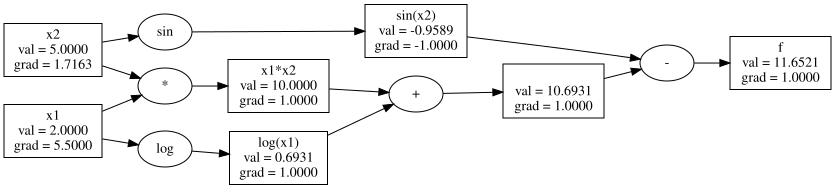

In [16]:
# 1. Initialize Inputs
x1 = Value(2.0, label='x1')
x2 = Value(5.0, label='x2')

# 2. Forward pass, build graph
# f = ln(x1) + x1*x2 - sin(x2)
t1 = x1.log();    t1.label = 'log(x1)'
t2 = x1 * x2;     t2.label = 'x1*x2'
t3 = x2.sin();    t3.label = 'sin(x2)'
f = t1 + t2 - t3; f.label  = 'f'
print(f"f      = {f.val:.4f}")
print(f)
print(t1)
print(t2)
print(t3)
print(x1)
print(x2)
print(10*'-')

# 3. Backward Pass
f.backward()
print(f)
print(t1)
print(t2)
print(t3)
print(x1)
print(x2)
print(f"df/dx1 = {x1.grad:.4f}")
print(f"df/dx2 = {x2.grad:.4f}")

# 4. Visualize
# This will render the image in the notebook, this will display a Directed Acyclic Graph (DAG).
draw_dot(f)

## 4. Summary comparison

| Feature | Forward Mode | Reverse Mode |
| :--- | :--- | :--- |
| **Primary Use Case** | Functions with few inputs, many outputs. | Functions with many inputs, few outputs (Neural Nets). |
| **Complexity** | O(inputs) | O(outputs) |
| **Memory** | Low (stores current values only). | High (must store the whole graph for the backward pass). |
| **Implementation** | Dual Numbers. | Computational Graph (Wengert List). |


## 5. Closing thoughts
We have just implemented the core logic of PyTorch. In a real library, these operations are vectorized (using tensors) and written in C++/CUDA for speed, but the logical flow—building a graph and propagating gradients backward via the chain rule—is exactly what you see here.